✅ File Loaded Successfully
                   Rating    Reviews
Category                            
EDUCATION        4.400000    57645.0
ENTERTAINMENT    4.250000  1238948.0
FAMILY           4.395455  4544623.0
GAME             4.313333  2397589.0
LIFESTYLE        4.380000    42809.0
PERSONALIZATION  4.475000   155996.0
PHOTOGRAPHY      4.150000   563720.0
SHOPPING         4.200000    19950.0
SPORTS           4.342857  1982017.0
TOOLS            4.200000     8010.0


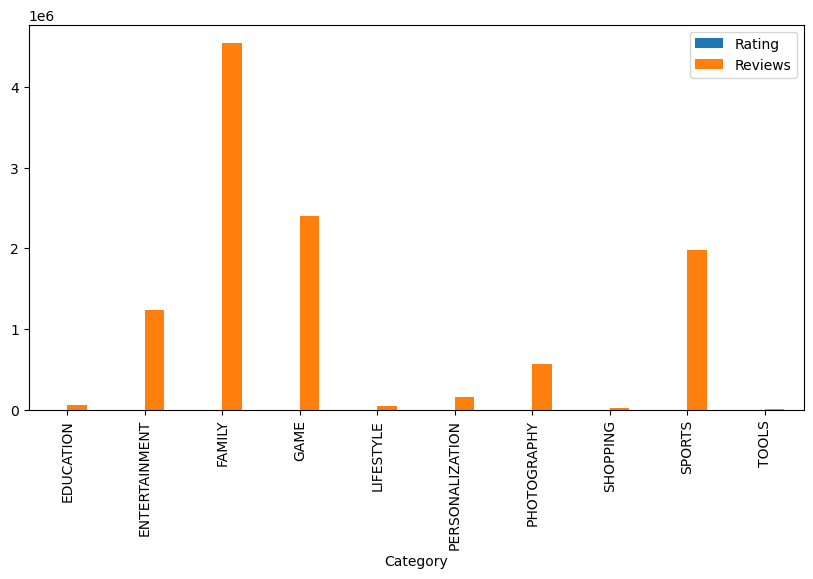

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Mrunal Athawale\Downloads\archive\googleplaystore.csv")

print("✅ File Loaded Successfully")

# Fix Installs
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Other columns
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Fix Size
def convert_size(size):
    try:
        if 'M' in str(size):
            return float(size.replace('M', ''))
        else:
            return None
    except:
        return None

df['Size_MB'] = df['Size'].apply(convert_size)

# Date
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Filtering
df = df[(df['Rating'] >= 4) & (df['Size_MB'] >= 10) & (df['Last Updated'].dt.month == 1)]

# Top 10
top = df.groupby('Category')['Installs'].sum().nlargest(10).index
df = df[df['Category'].isin(top)]

# Aggregate
grouped = df.groupby('Category').agg({'Rating':'mean','Reviews':'sum'})

print(grouped)

# Plot
grouped.plot(kind='bar', figsize=(10,5))
plt.show()